
# Strava / Bellabeat — Full Dataset Analysis

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
D_Activity=pd.read_csv('Strava Activity Analyzer/dailyActivity_merged.csv',encoding='ISO-8859-1')
D_Calories=pd.read_csv('Strava Activity Analyzer/dailyCalories_merged.csv',encoding='ISO-8859-1')
D_intensities=pd.read_csv('Strava Activity Analyzer/dailyIntensities_merged.csv',encoding='ISO-8859-1') 
D_steps=pd.read_csv('Strava Activity Analyzer/dailySteps_merged.csv',encoding='ISO-8859-1')
D_heartrate=pd.read_csv('Strava Activity Analyzer/heartrate_seconds_merged.csv',encoding='ISO-8859-1')
D_hourly_Cal=pd.read_csv('Strava Activity Analyzer/hourlyCalories_merged.csv',encoding='ISO-8859-1') 
D_hourly_int=pd.read_csv('Strava Activity Analyzer/hourlyIntensities_merged.csv',encoding='ISO-8859-1') 
D_hourly_step=pd.read_csv('Strava Activity Analyzer/hourlySteps_merged.csv',encoding='ISO-8859-1') 
D_Min_cal=pd.read_csv('Strava Activity Analyzer/minuteCaloriesNarrow_merged.csv',encoding='ISO-8859-1') 
D_min_wide=pd.read_csv('Strava Activity Analyzer/minuteCaloriesWide_merged.csv',encoding='ISO-8859-1') 
D_min_narrow=pd.read_csv('Strava Activity Analyzer/minuteIntensitiesNarrow_merged.csv',encoding='ISO-8859-1') 
D_min_int_wide=pd.read_csv('Strava Activity Analyzer/minuteIntensitiesWide_merged.csv',encoding='ISO-8859-1') 
D_min_MET=pd.read_csv('Strava Activity Analyzer/minuteMETsNarrow_merged.csv',encoding='ISO-8859-1') 
D_Min_sleep=pd.read_csv('Strava Activity Analyzer/minuteSleep_merged.csv',encoding='ISO-8859-1') 
D_min_step_narr=pd.read_csv('Strava Activity Analyzer/minuteStepsNarrow_merged.csv',encoding='ISO-8859-1') 
D_min_wide=pd.read_csv('Strava Activity Analyzer/minuteStepsWide_merged.csv',encoding='ISO-8859-1') 
D_sleep_day=pd.read_csv('Strava Activity Analyzer/sleepDay_merged.csv',encoding='ISO-8859-1')
D_Weight_log=pd.read_csv('Strava Activity Analyzer/weightLogInfo_merged.csv',encoding='ISO-8859-1') 

In [3]:
(D_Weight_log['Fat'].isnull().sum()/len(D_Weight_log))*100


np.float64(97.01492537313433)

In [4]:
D_Weight_log.drop('Fat',axis=1,inplace=True)



In [5]:
D_Activity=pd.read_csv('Strava Activity Analyzer/dailyActivity_merged.csv',encoding='ISO-8859-1')

D_Activity['ActivityDate']=pd.to_datetime(D_Activity['ActivityDate'])

D_Activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes  

## 1] Steps Trend → Line Chart

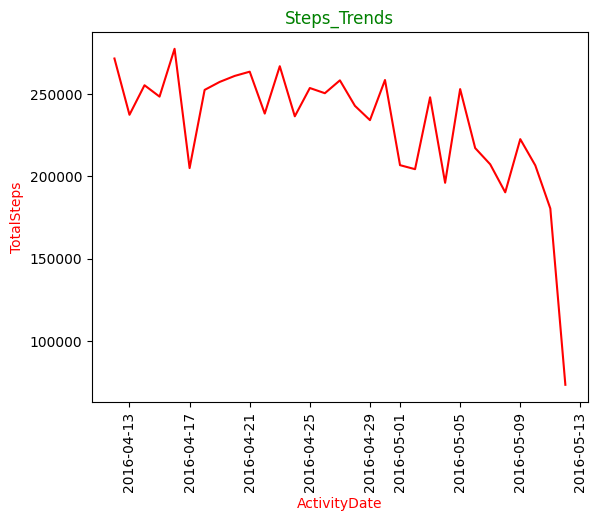

ActivityDate
2016-04-12    271816
2016-04-13    237558
2016-04-14    255538
2016-04-15    248617
2016-04-16    277733
2016-04-17    205096
2016-04-18    252703
2016-04-19    257557
2016-04-20    261215
2016-04-21    263795
2016-04-22    238284
2016-04-23    267124
2016-04-24    236621
2016-04-25    253849
2016-04-26    250688
2016-04-27    258516
2016-04-28    242996
2016-04-29    234289
2016-04-30    258726
2016-05-01    206870
2016-05-02    204434
2016-05-03    248203
2016-05-04    196149
2016-05-05    253200
2016-05-06    217287
2016-05-07    207386
2016-05-08    190334
2016-05-09    222718
2016-05-10    206737
2016-05-11    180468
2016-05-12     73129
Name: TotalSteps, dtype: int64


In [6]:
Step_trend=D_Activity.groupby('ActivityDate')['TotalSteps'].sum()
plt.plot(Step_trend.index,Step_trend.values,color='red')
plt.xticks(rotation=90)
plt.xlabel('ActivityDate',color='red')
plt.ylabel('TotalSteps',color='red'),
plt.title('Steps_Trends',color='green')

plt.show()
print(Step_trend)

##  Insight: Daily walking trend  

##  2. Calories Burned → Histogram

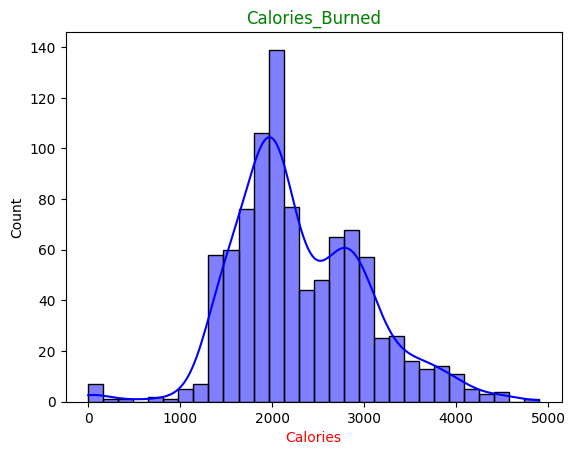

In [7]:
sns.histplot(data=D_Activity,x='Calories',kde=True,bins=30,color='blue')
plt.title('Calories_Burned',color='green')
plt.xlabel('Calories',color='red')
plt.show()

## Insight:  Average calories distribution



## 3. Top Active Users → Bar Chart

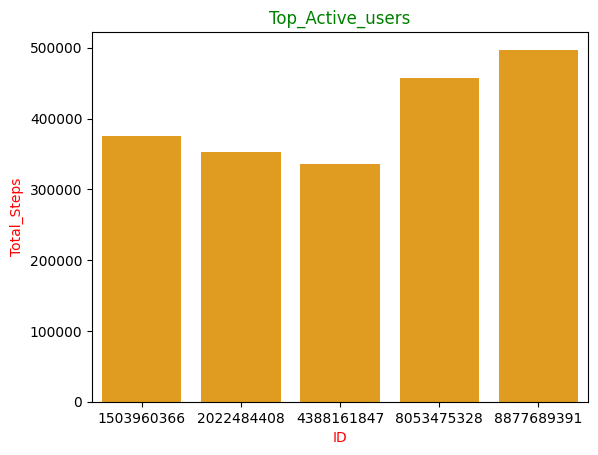

           Id  TotalSteps
0  8877689391      497241
1  8053475328      457662
2  1503960366      375619
3  2022484408      352490
4  4388161847      335232


In [8]:
a = D_Activity.groupby('Id')['TotalSteps'].sum().sort_values(ascending=False).head(5).reset_index()

sns.barplot(data=a, x='Id', y='TotalSteps',color='orange')
plt.title('Top_Active_users',color='green')
plt.xlabel('ID',color='red')
plt.ylabel('Total_Steps',color='red')

plt.show()
print(a)

## Insight: Most active users

## 4. Steps vs Calories → Scatter Plot

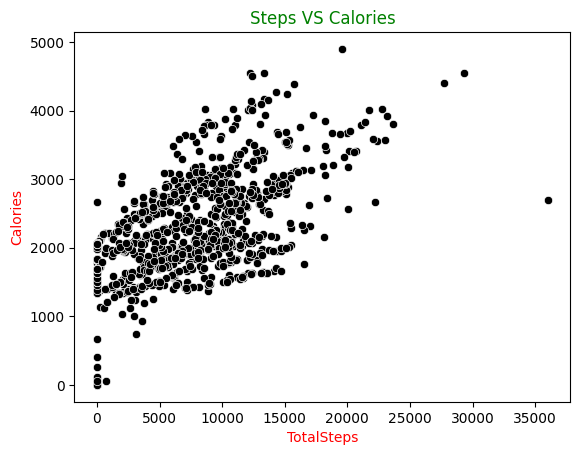

In [9]:
sns.scatterplot(x='TotalSteps', y='Calories', data=D_Activity,color='black')
plt.title('Steps VS Calories',color='green')
plt.xlabel('TotalSteps',color='red')
plt.ylabel('Calories',color='red')
plt.show()

## Insight: More steps → more calories burn

## 5] Sleep Analysis → Histogram 

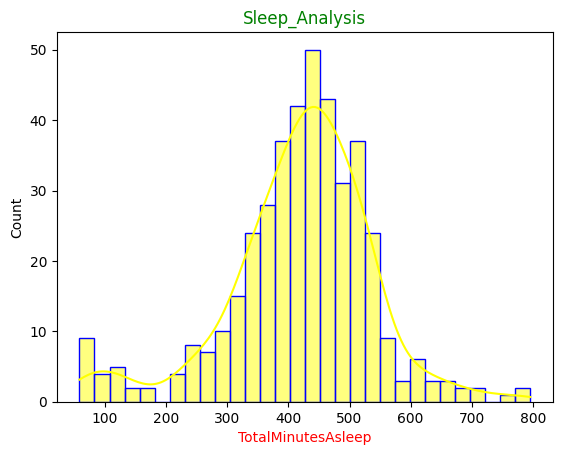

In [10]:
D_sleep_day=pd.read_csv('Strava Activity Analyzer/sleepDay_merged.csv',encoding='ISO-8859-1')
sns.histplot(data=D_sleep_day,x='TotalMinutesAsleep',kde=True,bins=30,color='yellow',edgecolor='blue')
plt.title('Sleep_Analysis',color='green')
plt.xlabel('TotalMinutesAsleep',color='red')
plt.show()

## Insight: Sleep behavior analysis

## 6] Weekday Activity → Countplot

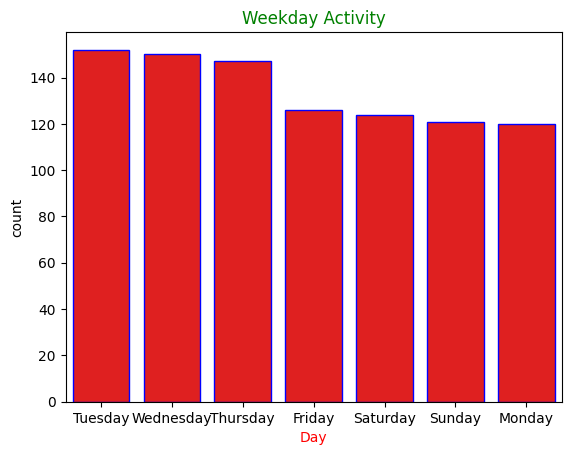

In [11]:
D_Activity['Day'] = pd.to_datetime(D_Activity['ActivityDate']).dt.day_name()
sns.countplot(x='Day', data=D_Activity,color='red',edgecolor='blue')
plt.title('Weekday Activity',color='green')
plt.xlabel('Day',color='red')
plt.show()

## Insight: Most active weekday

## 8]Distance Covered → Line

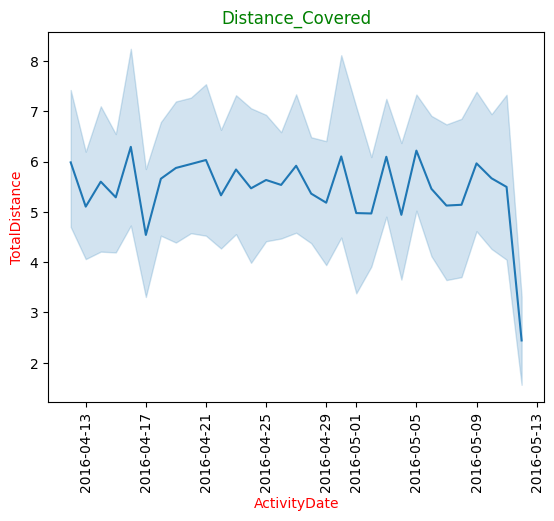

In [12]:
sns.lineplot(x='ActivityDate', y='TotalDistance', data=D_Activity)
plt.title('Distance_Covered',color='green')
plt.xlabel('ActivityDate',color='red')
plt.ylabel('TotalDistance',color='red')
plt.xticks(rotation=90)
plt.show()

## Insight: Travel/activity distance trend

## 9]Sleep vs Calories → Scatter Plot

In [15]:
# D_sleep_day['SleepDay']=pd.to_datetime(D_sleep_day['SleepDay'],format=('%d-%b-%y'),dayfirst=True)
D_sleep_day


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712
...,...,...,...,...,...
408,8792009665,4/30/2016 12:00:00 AM,1,343,360
409,8792009665,5/1/2016 12:00:00 AM,1,503,527
410,8792009665,5/2/2016 12:00:00 AM,1,415,423
411,8792009665,5/3/2016 12:00:00 AM,1,516,545


In [34]:
merged_df = pd.merge(
    D_sleep_day,
    D_Activity,
    left_on=['Id','SleepDay'],
    right_on=['Id','ActivityDate']
)




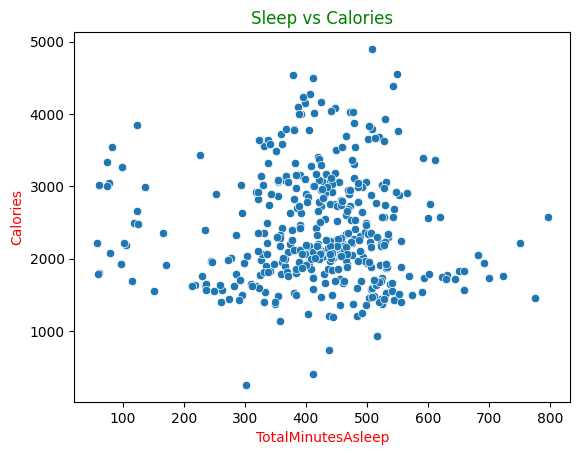

In [63]:
sns.scatterplot(
    x='TotalMinutesAsleep',
    y='Calories',
    data=merged_df
)
plt.title('Sleep vs Calories',color='green')
plt.xlabel('TotalMinutesAsleep',color='red')
plt.ylabel('Calories',color='red')

plt.show()

## Insight: More sleep users burn more calories/activity.

## 10] Sleep vs Active Minutes → Bar Plot

In [69]:
merged_df['SleepCategory'] = pd.cut(
    merged_df['TotalMinutesAsleep'],
    bins=[0,300,500,800],
    labels=['Low Sleep','Medium Sleep','High Sleep']
)

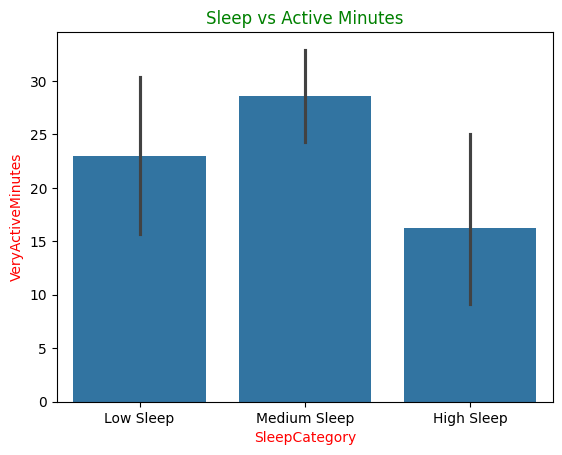

In [70]:
sns.barplot(
    x='SleepCategory',
    y='VeryActiveMinutes',
    data=merged_df
)
plt.title('Sleep vs Active Minutes',color='green')
plt.xlabel('SleepCategory',color='red')
plt.ylabel('VeryActiveMinutes',color='red')

plt.show()

## Insight: Users with proper sleep may have better activity levels.